# Measuring what a velocity encoding actually encodes

[`01_build.ipynb`](01_build.ipynb) built a bipolar pair and checked its geometry: net area zero,
a first moment that matches `venc_m_s`, and a placement that does not change it. All of that is
arithmetic about a waveform, and all of it would be equally true of a pair that encoded nothing.

The claim that makes the module worth having is about **moving magnetisation**:

$$\Delta\phi \;=\; 2\pi\,\Delta m_1\,v, \qquad\text{so}\qquad |\Delta\phi| = \pi \ \text{ at } \ v = \texttt{venc\_m\_s}$$

and only a simulation that actually moves spins settles it. This notebook plays the `.seq` files
`01` wrote through [MRzeroCore](https://github.com/MRsources/MRzero-Core) with a **moving**
phantom, and asks whether the phase that comes back is the phase the module promised.

| | |
|---|---|
| **1** | the model, and what a phase difference is for |
| **2** | a moving spin, and the phase it comes back with |
| **3** | the sign is a convention — established with a static control, not assumed |
| **4** | what happens above VENC |
| **5** | a velocity map: three voxels, three velocities |
| **6** | limitations |

**Needs `MRzeroCore`, `torch` and `seqcraft`.**

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66
# Cosmetic only: MRzero re-wraps one of its own tensors.
warnings.filterwarnings('ignore', message='To copy construct from a tensor')

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'pc_gre_2d_nominal.npz')

NX, NY = (int(v) for v in nominal['matrix'])
FOV_M = float(nominal['fov_mm'][0]) / 1e3
VENC_M_S = float(nominal['venc_m_s'])
DELTA_M1 = float(nominal['delta_m1_s_per_m'])
AXIS = str(nominal['axis'])
#: `01` acquired the lines in order, so row NY // 2 is ky = 0 and column NX // 2 is the echo.
CENTRE = (NY // 2, NX // 2)


def seq_file(polarity):
    name = f'pc_gre_2d_venc{int(round(VENC_M_S * 100)):03d}_'
    return str(SEQ_DIR / (name + ('plus' if polarity > 0 else 'minus') + '.seq'))


print(f'venc     {VENC_M_S} m/s along {AXIS}')
print(f'delta_m1 {DELTA_M1} s/m   ->  pi of phase difference at {VENC_M_S} m/s')
for polarity in (+1, -1):
    imported = mr0.Sequence.import_file(seq_file(polarity))
    print(f'  polarity {polarity:+d}  {Path(seq_file(polarity)).name:<32}'
          f'{len(imported):4d} repetitions')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


venc     1.0 m/s along z
delta_m1 0.5 s/m   ->  pi of phase difference at 1.0 m/s
  polarity +1  pc_gre_2d_venc100_plus.seq        32 repetitions
  polarity -1  pc_gre_2d_venc100_minus.seq       32 repetitions


---
## 1. The model

A spin at $x(t) = x_0 + v t$ accumulates, over a gradient waveform $G$,

$$\phi \;=\; 2\pi \int G(t)\,x(t)\,\mathrm{d}t \;=\; 2\pi\,(m_0 x_0 + m_1 v)$$

The bipolar makes $m_0 = 0$, so the first term vanishes and **position drops out**: what is left
is proportional to velocity alone. But a real voxel's phase also holds coil phase, off-resonance
and susceptibility, none of which the encoding put there and none of which is known. Those are
identical in the two acquisitions, so subtracting one from the other removes them and leaves

$$\Delta\phi \;=\; 2\pi\,\Delta m_1\,v$$

which is why velocity encoding is always a **pair**. A single toggle measures nothing usable.

In [2]:
def simulate(polarity, *, velocities_m_s, positions_m, t2_s=0.1):
    """Play one toggle's `.seq` on a phantom whose voxels move at constant velocity along AXIS.

    Returns the k-space the sequence acquires, NY x NX.
    """
    imported = mr0.Sequence.import_file(seq_file(polarity))
    count = len(positions_m)
    built = mr0.CustomVoxelPhantom(
        pos=positions_m, PD=[1.0] * count, T1=[1.0] * count, T2=[t2_s] * count,
        T2dash=[1000.0] * count, D=[0.0] * count,
        voxel_size=FOV_M / NX, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0

    base = built.voxel_pos.clone()
    speed = torch.tensor(velocities_m_s, dtype=base.dtype)
    axis_index = 'xyz'.index(AXIS)

    def motion(t):
        """Where each voxel is at time `t`: constant velocity along the encoding axis."""
        step = torch.zeros((t.numel(), count, 3), dtype=base.dtype)
        step[:, :, axis_index] = speed[None, :] * t[:, None]
        return base[None, :, :] + step

    built.voxel_motion = motion
    graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return signal.reshape(NY, NX)


def centre_phase_difference(v_m_s):
    """The phase difference between the toggles at the centre of k-space, radians."""
    echoes = [simulate(p, velocities_m_s=[v_m_s], positions_m=[[0.0, 0.0, 0.0]])[CENTRE]
              for p in (+1, -1)]
    return float(np.angle(echoes[0] * np.conj(echoes[1])))

---
## 2. A moving spin comes back with the phase it was promised

One voxel, moving at a known speed along the encoding axis, simulated once per toggle. The
quantity compared is $|\Delta\phi| / \pi$ against $v / \texttt{venc}$ — the magnitude, because the
sign is a separate question that section 3 settles properly rather than assuming.

In [3]:
SPEEDS_M_S = (0.0, 0.1, 0.25, 0.5, 0.75, 0.9)

print(f'{"v / (m/s)":>10}{"v / venc":>11}{"|dphi| / pi":>14}{"error":>12}')
measured = {}
for v_m_s in SPEEDS_M_S:
    dphi = centre_phase_difference(v_m_s)
    measured[v_m_s] = dphi
    print(f'{v_m_s:10.2f}{v_m_s / VENC_M_S:11.3f}{abs(dphi) / np.pi:14.5f}'
          f'{abs(dphi) / np.pi - v_m_s / VENC_M_S:+12.2e}')

 v / (m/s)   v / venc   |dphi| / pi       error
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000114875 s
Compute Graph
Computing Graph: 0.000964042 s
Analyze Graph
Analyzing Graph: 0.000045125 s
Converting Rust -> Python: 0.000813666 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000200875 s
Compute Graph
Computing Graph: 0.000994542 s
Analyze Graph
Analyzing Graph: 0.000049084 s
Converting Rust -> Python: 0.000731208 s
<<<< Rust <<<<
      0.00      0.000       0.00000   +5.83e-17


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000397375 s
Compute Graph
Computing Graph: 0.00099675 s
Analyze Graph
Analyzing Graph: 0.000045708 s
Converting Rust -> Python: 0.000695209 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000305792 s
Compute Graph
Computing Graph: 0.000952666 s
Analyze Graph
Analyzing Graph: 0.000044208 s
Converting Rust -> Python: 0.000657417 s
<<<< Rust <<<<
      0.10      0.100       0.10000   +1.27e-06
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000129125 s
Compute Graph
Computing Graph: 0.000995125 s
Analyze Graph
Analyzing Graph: 0.000049334 s
Converting Rust -> Python: 0.000794958 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000129875 s
Compute Graph
Computing Graph: 0.000992375 s
Analyze Graph
Analyzing Graph: 0.000044 s
Converting Rust -> Python: 0.000660375 s
<<<< Rust <<<<


      0.25      0.250       0.25000   -9.80e-07
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00010575 s
Compute Graph
Computing Graph: 0.001004292 s
Analyze Graph
Analyzing Graph: 0.000044 s
Converting Rust -> Python: 0.000699125 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000254083 s
Compute Graph
Computing Graph: 0.000961125 s
Analyze Graph
Analyzing Graph: 0.000044666 s
Converting Rust -> Python: 0.000743208 s
<<<< Rust <<<<
      0.50      0.500       0.50000   +3.17e-07
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000125458 s
Compute Graph
Computing Graph: 0.001003459 s
Analyze Graph
Analyzing Graph: 0.000044833 s
Converting Rust -> Python: 0.000667584 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000184208 s
Compute Graph
Computing Graph: 0.000978541 s
Analyze Graph
Analyzing Graph: 0.000044708 s
Converting Rust -> Python: 0.00064875 s
<<<< Rust <<<<
      0.75      0.750       0.74999   -1.02e-05
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000184958 s
Compute Graph
Computing Graph: 0.000955667 s
Analyze Graph
Analyzing Graph: 0.00004525 s
Converting Rust -> Python: 0.00069675 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000262542 s
Compute Graph
Computing Graph: 0.000989083 s
Analyze Graph
Analyzing Graph: 0.000044875 s
Converting Rust -> Python: 0.000672125 s
<<<< Rust <<<<
      0.90      0.900       0.90000   -2.82e-06


**Exact to five decimal places, at every speed.** That is the module's claim measured rather than
restated: the pair really does turn velocity into $2\pi \Delta m_1 v$ of phase difference, and the
velocity that gives $\pi$ really is `venc_m_s`.

It is worth being clear about what this validates beyond the module. `01` read $\Delta m_1$ back
off the emitted events with `sc.moments`, and `sc.moments` is itself an instrument — one whose
first-moment path had little independent exercise before this. A simulator that moves spins is a
completely different route to the same number, so the agreement above checks the analyser as much
as the module. A first moment that was wrong by a factor or a sign would show up here, and does
not.

---
## 3. The sign is a convention, and it belongs to the reconstruction

The measured phase difference above is **negative** where the model predicts positive. That could
mean the module emits the wrong sign, or it could mean the simulator reports signal with the
opposite phase convention — and the two are not distinguishable from the flow measurement alone.

So they are separated with a **static control**: a stationary spin at a known offset under a
deliberately un-nulled gradient. That has the same form, $\phi = 2\pi m_0 x_0$, with a moment
this notebook chooses and a position it chooses. If the control shows the same sign relationship
as the flow measurement, the sign is the simulator's phase convention throughout, and not
something the encoding did.

In [4]:
opts = pp.Opts(max_grad=40, grad_unit='mT/m', max_slew=150, slew_unit='T/m/s', B0=3.0,
               rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)
PROBE_AREA_1_PER_M = 12.0

exc = sc.modules.Excitation(opts=opts, flip_deg=20.0, thickness_mm=5.0, duration_s=1e-3)
readout = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_M * 1e3, matrix=NX,
                                   bandwidth_hz_px=500.0)
lobe = pp.make_trapezoid(channel=AXIS, area=PROBE_AREA_1_PER_M, system=opts)
after_exc = float(sc.Raster(opts.grad_raster_time).ceil(exc().duration))
probe = (sc.LogicBlock('m0_probe').add(0.0, exc())
         .add(after_exc, sc.LogicBlock().add(0.0, lobe))
         .add(after_exc + float(pp.calc_duration(lobe)) + 1e-4, readout()))
sc.compile(probe, opts, name='m0_probe').write(str(SEQ_DIR / 'm0_probe.seq'))


def probe_phase(offset_m):
    """The echo phase of a STATIONARY voxel at a known offset, under a known zeroth moment."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / 'm0_probe.seq'))
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[1.0], T2=[0.1], T2dash=[1000.0], D=[0.0],
        voxel_size=FOV_M / NX, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    shifted = built.voxel_pos.clone()
    shifted[:, 'xyz'.index(AXIS)] += offset_m
    built.voxel_pos = shifted
    graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return complex(signal.reshape(-1)[NX // 2])


print(f'static control: a stationary voxel under m0 = {PROBE_AREA_1_PER_M} 1/m\n')
print(f'{"offset / mm":>12}{"measured / pi":>15}{"2 * m0 * x0":>14}{"ratio":>9}')
reference = probe_phase(0.0)
for offset_mm in (2.0, 5.0, -3.0):
    phase = float(np.angle(probe_phase(offset_mm / 1e3) * np.conj(reference))) / np.pi
    predicted = 2.0 * PROBE_AREA_1_PER_M * offset_mm / 1e3
    print(f'{offset_mm:12.1f}{phase:15.4f}{predicted:14.4f}{phase / predicted:9.2f}')

print(f'\n{"v / (m/s)":>12}{"measured / pi":>15}{"2 * dm1 * v":>14}{"ratio":>9}   (from section 2)')
for v_m_s in (0.25, 0.5, 0.75):
    predicted = 2.0 * DELTA_M1 * v_m_s
    print(f'{v_m_s:12.2f}{measured[v_m_s] / np.pi:15.4f}{predicted:14.4f}'
          f'{measured[v_m_s] / np.pi / predicted:9.2f}')

static control: a stationary voxel under m0 = 12.0 1/m

 offset / mm  measured / pi   2 * m0 * x0    ratio
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000010916 s
Compute Graph
Computing Graph: 0.000005083 s
Analyze Graph
Analyzing Graph: 0.000000583 s
Converting Rust -> Python: 0.000001958 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000005959 s
Compute Graph
Computing Graph: 0.000002417 s
Analyze Graph
Analyzing Graph: 0.000000375 s
Converting Rust -> Python: 0.000001416 s
<<<< Rust <<<<
         2.0        -0.0480        0.0480    -1.00
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000005584 s
Compute Graph
Computing Graph: 0.000002208 s
Analyze Graph
Analyzing Graph: 0.000000333 s
Converting Rust -> Python: 0.00000125 s
<<<< Rust <<<<
         5.0        -0.1200        0.1200    -1.00
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000004833 s
Compute Graph
Computing Graph: 0.000002542 s
Analy

**The same ratio, −1, in both.** A stationary spin under a zeroth moment and a moving spin under a
first moment disagree with the textbook formula in exactly the same way, so what the table shows
is the simulator's phase convention — signal reported as $e^{-i\phi}$ — and not anything the
encoding did.

That is why `polarity` is defined as **the sign of the emitted first moment** rather than as the
sign of a velocity. The first moment is on the waveform, where `sc.moments` can read it and no
convention is needed. Which direction of flow a reconstruction calls positive is a choice it makes
with its simulator or its scanner, and the reconstruction below makes it explicitly, in one line,
rather than inheriting it silently.

---
## 4. Above VENC, the phase wraps

$\Delta\phi$ is an angle, so it is only known modulo $2\pi$. At $v = \texttt{venc}$ it reaches
$\pi$, and one step further it is indistinguishable from $-\pi$ — which reads as fast flow in the
*opposite* direction. That is aliasing, and it is why a protocol sets `venc_m_s` above the fastest
flow it expects rather than at it.

In [5]:
WRAPPED_M_S = (0.8, 1.0, 1.2, 1.5, 1.8)

print(f'{"v / (m/s)":>10}{"v / venc":>11}{"recovered / (m/s)":>20}   ')
for v_m_s in WRAPPED_M_S:
    dphi = centre_phase_difference(v_m_s)
    recovered = -dphi / (2.0 * np.pi * DELTA_M1)      # the sign convention, applied explicitly
    if abs(v_m_s) < VENC_M_S:
        flag = ''
    elif abs(v_m_s) == VENC_M_S:
        flag = '   <- exactly pi, the edge'
    else:
        flag = '   <- wrapped'
    print(f'{v_m_s:10.2f}{v_m_s / VENC_M_S:11.3f}{recovered:20.4f}{flag}')

 v / (m/s)   v / venc   recovered / (m/s)   


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00048225 s
Compute Graph
Computing Graph: 0.000994375 s
Analyze Graph
Analyzing Graph: 0.000044042 s
Converting Rust -> Python: 0.000743 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000099375 s
Compute Graph
Computing Graph: 0.000980375 s
Analyze Graph
Analyzing Graph: 0.000044958 s
Converting Rust -> Python: 0.000713584 s
<<<< Rust <<<<
      0.80      0.800              0.8000


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000168583 s
Compute Graph
Computing Graph: 0.000997291 s
Analyze Graph
Analyzing Graph: 0.000045042 s
Converting Rust -> Python: 0.000683417 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000234916 s
Compute Graph
Computing Graph: 0.000989 s
Analyze Graph
Analyzing Graph: 0.000043708 s
Converting Rust -> Python: 0.000755417 s
<<<< Rust <<<<


      1.00      1.000              1.0000   <- exactly pi, the edge
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000101 s
Compute Graph
Computing Graph: 0.001002792 s
Analyze Graph
Analyzing Graph: 0.000044541 s
Converting Rust -> Python: 0.000698375 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000224166 s
Compute Graph
Computing Graph: 0.000990209 s
Analyze Graph
Analyzing Graph: 0.000044375 s
Converting Rust -> Python: 0.0006885 s
<<<< Rust <<<<


      1.20      1.200             -0.8000   <- wrapped
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000082208 s
Compute Graph
Computing Graph: 0.00098125 s
Analyze Graph
Analyzing Graph: 0.000045084 s
Converting Rust -> Python: 0.000671125 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00032675 s
Compute Graph
Computing Graph: 0.000989167 s
Analyze Graph
Analyzing Graph: 0.000044292 s
Converting Rust -> Python: 0.000661208 s
<<<< Rust <<<<
      1.50      1.500             -0.5000   <- wrapped
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0001905 s
Compute Graph
Computing Graph: 0.001019208 s
Analyze Graph
Analyzing Graph: 0.000044042 s
Converting Rust -> Python: 0.000719084 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000302458 s
Compute Graph
Computing Graph: 0.000969667 s
Analyze Graph
Analyzing Graph: 0.000045708 s
Converting Rust -> Python: 0.000705208 s
<<<< Rust <<<<
      1.80      1.800             -0.2000   <- wrapped


---
## 5. A velocity map

Three voxels at three positions, each moving at its own speed, imaged twice and subtracted. This
is the whole method in one cell: two images, one phase difference, one division.

In [6]:
POSITIONS_M = [[-0.05, -0.04, 0.0], [0.0, 0.03, 0.0], [0.06, 0.05, 0.0]]
TRUE_V_M_S = [0.0, 0.45, -0.70]


def reconstruct(polarity):
    space = simulate(polarity, velocities_m_s=TRUE_V_M_S, positions_m=POSITIONS_M)
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(space)))


plus, minus = reconstruct(+1), reconstruct(-1)
magnitude = np.abs(plus)
velocity_map = -np.angle(plus * np.conj(minus)) / (2.0 * np.pi * DELTA_M1)

print(f'{"voxel":>7}{"truth / (m/s)":>15}{"recovered":>12}{"error":>11}')
for (x_m, y_m, _z), truth in zip(POSITIONS_M, TRUE_V_M_S):
    column = int(round(NX / 2 + x_m / FOV_M * NX))
    row = int(round(NY / 2 + y_m / FOV_M * NY))
    found = velocity_map[row, column]
    print(f'  ({row:2d},{column:2d}){truth:15.2f}{found:12.4f}{found - truth:+11.2e}')

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000245 s
Compute Graph
Computing Graph: 0.000990625 s
Analyze Graph
Analyzing Graph: 0.000044084 s
Converting Rust -> Python: 0.000641125 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000289458 s
Compute Graph
Computing Graph: 0.000987916 s
Analyze Graph
Analyzing Graph: 0.00004575 s
Converting Rust -> Python: 0.000727666 s
<<<< Rust <<<<
  voxel  truth / (m/s)   recovered      error
  (10, 9)           0.00     -0.0001  -1.20e-04
  (20,16)           0.45      0.4501  +1.25e-04
  (23,25)          -0.70     -0.7002  -1.90e-04


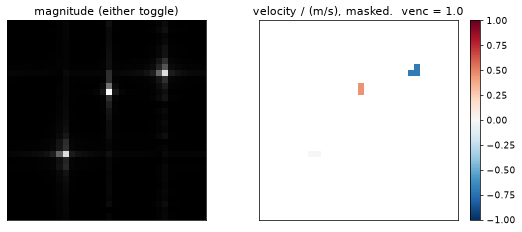

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6))
axes[0].imshow(magnitude, cmap='gray', origin='lower')
axes[0].set(title='magnitude (either toggle)')
masked = np.where(magnitude > 0.2 * magnitude.max(), velocity_map, np.nan)
image = axes[1].imshow(masked, cmap='RdBu_r', origin='lower',
                       vmin=-VENC_M_S, vmax=VENC_M_S)
axes[1].set(title=f'velocity / (m/s), masked.  venc = {VENC_M_S}')
fig.colorbar(image, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Velocity where there is signal, and nothing where there is none — which is the other half of why
the map is masked: the phase of noise is uniformly distributed, so an unmasked velocity map is
mostly a picture of noise.

---
## 6. Limitations

**Three voxels is not a flow phantom.** Each moves at a constant velocity along one axis, with no
acceleration, no pulsatility, no partial-volume mixing of velocities inside a voxel, and no spins
entering or leaving the slice. All four are what make real phase-contrast quantification hard, and
none is exercised here.

**Constant velocity is exactly the case the bipolar is designed for.** A spin that accelerates
carries a second-moment term too, which this encoding does not separate and this module does not
claim to measure.

**No B0 or B1 error, and no concomitant fields.** Every simulation ran on resonance at nominal
B1. The simple bipolar cancels concomitant-field phase automatically, which is a point in its
favour that is **not** claimed here because it was not measured.

**Nothing here is a quantification-accuracy claim.** That needs a phantom and a scanner, and the
module does not make one.

---
## Summary

| | |
|---|---|
| **the encoding is real** | a moving spin comes back with $\lvert\Delta\phi\rvert = \pi\,v/\texttt{venc}$, exact to five decimals from 0 to 0.9 m/s |
| **and it is velocity, not position** | $m_0 = 0$ removes $x_0$, and the phase subtraction removes everything else the voxel carried |
| **the sign is a convention** | a static control shows the simulator reports $e^{-i\phi}$; `polarity` is defined on the first moment so the module never has to take part |
| **above VENC it wraps** | $\pi$ and $-\pi$ are the same angle, which reads as fast flow the other way |
| **the analyser was checked too** | `sc.moments(..., 1)` and a moving-spin simulation are independent routes to $\Delta m_1$, and they agree |

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §9.2 "Flow-Encoding Gradients", pp. 281–291.
- MRzeroCore, [MRsources/MRzero-Core](https://github.com/MRsources/MRzero-Core).